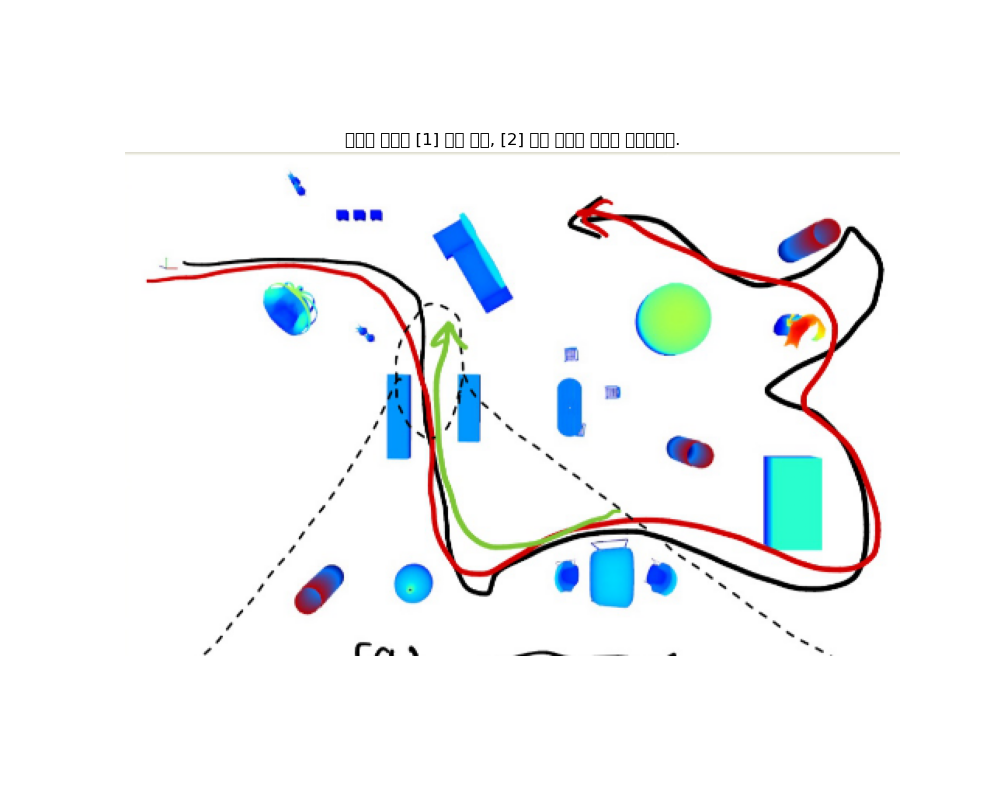

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg

# 대화형 플롯을 위해 백엔드를 설정합니다.
%matplotlib widget

# --- ⭐️ 설정이 필요한 부분 ---
# 사용할 배경 이미지 파일 경로를 지정하세요.
IMAGE_PATH = '/home/hsj/Downloads/1.png'  # 예: 'map.png', 'floor_plan.jpg'

# 이미지 로드
try:
    background_img = mpimg.imread(IMAGE_PATH)
except FileNotFoundError:
    print(f"오류: '{IMAGE_PATH}' 파일을 찾을 수 없습니다. 파일 경로를 확인해주세요.")
    # 임시로 1000x1000 크기의 빈 이미지를 생성합니다.
    background_img = np.ones((1000, 1000, 3))

# 사용자가 마우스로 클릭한 좌표를 저장할 리스트
clicked_coords = []

# Matplotlib Figure와 Axis를 생성합니다.
fig_click, ax_click = plt.subplots(figsize=(10, 8))
ax_click.imshow(background_img)
ax_click.set_title("이미지 위에서 [1] 로봇 위치, [2] 타겟 위치를 차례로 클릭하세요.")
plt.axis('off')

def onclick(event):
    """마우스 클릭 이벤트를 처리하는 함수"""
    if event.xdata is not None and event.ydata is not None:
        ix, iy = event.xdata, event.ydata
        clicked_coords.append(np.array([ix, iy]))
        
        # 클릭한 위치에 시각적으로 표시
        label = "Robot Pose" if len(clicked_coords) == 1 else "Target Pose"
        ax_click.plot(ix, iy, 'rx', markersize=12, mew=2)
        ax_click.text(ix + 5, iy + 5, f'[{len(clicked_coords)}] {label}', color='red', fontsize=12, fontweight='bold')
        fig_click.canvas.draw()
        
        print(f"[{len(clicked_coords)}] {label} 위치가 찍혔습니다: ({ix:.2f}, {iy:.2f})")

        if len(clicked_coords) == 2:
            print("\n✅ 기준점 설정 완료! 아래 [셀 2]를 실행하여 플롯을 이미지 위에 그리세요.")
            fig_click.canvas.mpl_disconnect(cid)

# 'button_press_event'에 onclick 함수를 연결
cid = fig_click.canvas.mpl_connect('button_press_event', onclick)

plt.show()

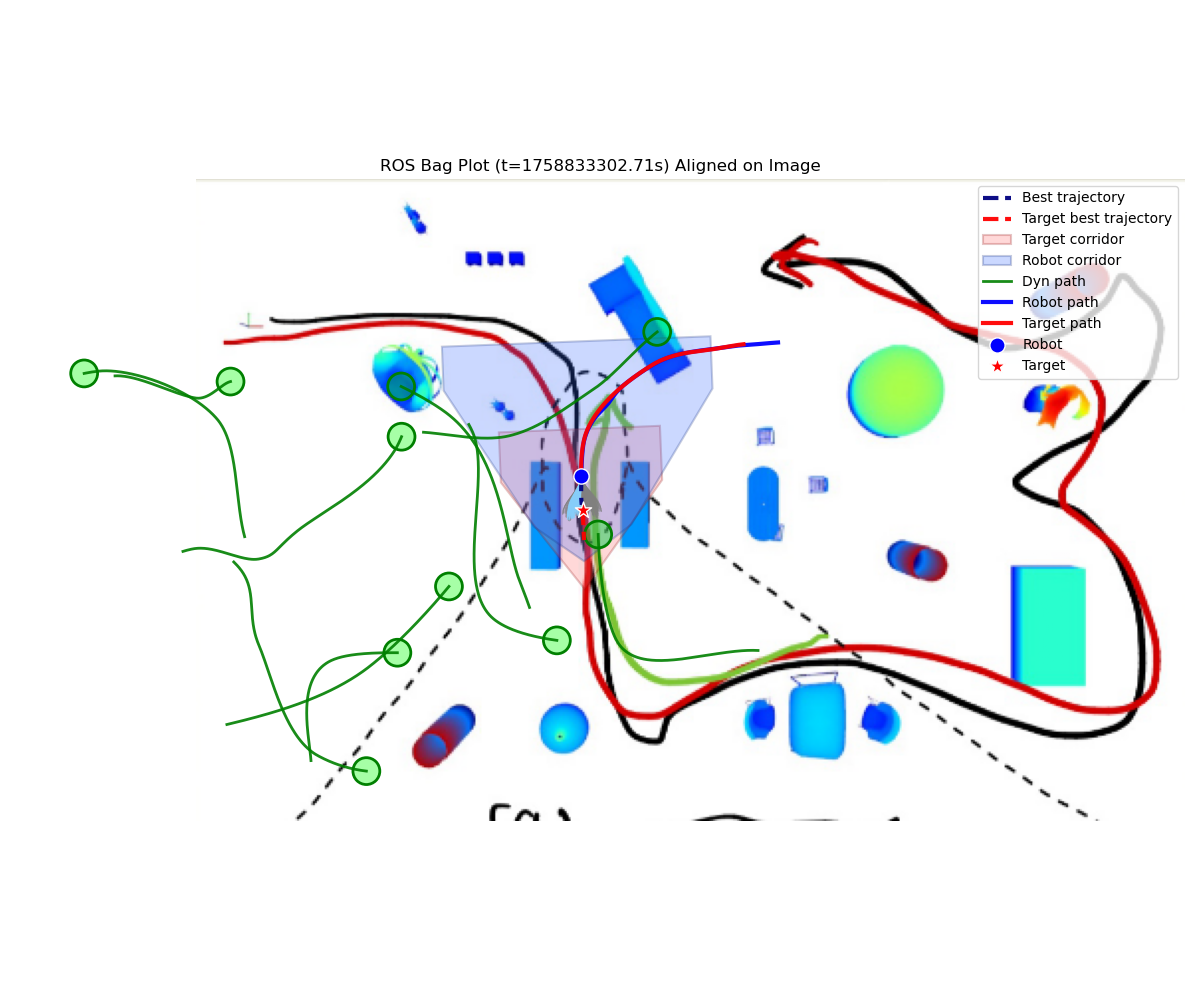

In [3]:
# %%capture --no-display
# 셀 1에서 기준점 설정이 완료되었는지 확인
if 'clicked_coords' not in locals() or len(clicked_coords) < 2:
    print("🛑 오류: [셀 1]을 먼저 실행해서 이미지 위에 기준점 2개를 찍어주세요.")
else:
    # ===================================================================================
    #
    #              ↓↓↓ 기존에 작성하신 rosbag 데이터 로딩 및 파싱 코드 ↓↓↓
    #         (이 부분은 거의 수정하지 않고 그대로 가져와 사용합니다)
    #
    # ===================================================================================
    from collections import defaultdict
    from typing import List, Tuple
    # numpy, matplotlib.pyplot 등은 이미 위에서 import 했습니다.
    from matplotlib.patches import Circle

    # -------------------- 설정 --------------------
    MODE = "ros1"
    BAG_PATH = "/home/hsj/Downloads/top_down.bag"
    TARGET_FRAME = "map"
    TF_TOPICS = ["/tf", "/tf_static"]
    TOPIC_OBS_LIST = "/bpmp_simulator/obstacle_state_list"
    FEAS_TOPICS = ["/bpmp_tracker/feasible_primitives"]
    RAW_TOPICS  = ["/bpmp_tracker/raw_primitive"]
    BEST_TOPICS = ["/bpmp_tracker/best_primitives"]
    CORRIDOR_T  = "/bpmp_predictor/corridor"
    CORRIDOR_R  = "/bpmp_tracker/corridor"
    ROBOT_POSE_TOPICS  = ["/airsim/gtpose"]
    TARGET_POSE_TOPICS = ["/airsim/object/target/pose", "/target_pose", "/bpmp_simulator/target_state"]
    TARGET_BEST_TOPIC = ["/bpmp_predictor/TargetBestPrimitive"]
    USE_ABS_TIME = False
    T_OFFSET_SEC = 15.9
    ABS_TIME_SEC = 0.0
    PATH_WINDOW_SEC = 10.0
    CYL_RADIUS = 0.5
    SLICE_Z = 0.3
    SLICE_EPS = 0.5

    # ... (기존 유틸리티 함수들: pick_closest, pose_xyz_from_any, 등등)
    # ... (여기에 제공해주신 모든 유틸리티 함수들을 그대로 붙여넣습니다)
    def pick_closest(msg_list: List[Tuple[float, object]], t_query: float):
        if not msg_list: return None
        idx = int(np.argmin([abs(t - t_query) for t, _ in msg_list]))
        return msg_list[idx]

    def pose_xyz_from_any(msg):
        if hasattr(msg, "pose") and hasattr(msg.pose, "pose") and hasattr(msg.pose.pose, "position"):
            p = msg.pose.pose.position; return np.array([p.x, p.y, p.z]), getattr(msg, 'header', None)
        if hasattr(msg, "pose") and hasattr(msg.pose, "position"):
            p = msg.pose.position; return np.array([p.x, p.y, p.z]), getattr(msg, 'header', None)
        if hasattr(msg, "px") and hasattr(msg, "py") and hasattr(msg, "pz"):
            return np.array([msg.px, msg.py, msg.pz]), None
        return None, None

    def hull2d_monotone_chain(points_xy: np.ndarray):
        pts = np.unique(points_xy, axis=0)
        if len(pts) <= 1: return pts
        pts = pts[pts[:,0].argsort(kind='mergesort')]
        def cross(o, a, b): return (a[0]-o[0])*(b[1]-o[1]) - (a[1]-o[1])*(b[0]-o[0])
        lower = []
        for p in pts:
            while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0: lower.pop()
            lower.append(tuple(p))
        upper = []
        for p in reversed(pts):
            while len(upper) >= 2 and cross(upper[-2], upper[-1], p) <= 0: upper.pop()
            upper.append(tuple(p))
        return np.array(lower[:-1] + upper[:-1])

    def quat_to_R(x,y,z,w):
        xx, yy, zz = x*x, y*y, z*z; xy, xz, yz = x*y, x*z, y*z; wx, wy, wz = w*x, w*y, w*z
        return np.array([[1-2*(yy+zz), 2*(xy-wz), 2*(xz+wy)], [2*(xy+wz), 1-2*(xx+zz), 2*(yz-wx)], [2*(xz-wy), 2*(yz+wx), 1-2*(xx+yy)]])

    def build_tf_store(storage):
        from collections import defaultdict as _dd; tf_store = _dd(list)
        for tf_topic in TF_TOPICS:
            for ts, msg in storage.get(tf_topic, []):
                for tr in getattr(msg, 'transforms', []):
                    parent = getattr(getattr(tr, 'header', None), 'frame_id', ''); child  = getattr(tr, 'child_frame_id', '')
                    t = getattr(tr, 'transform', None);
                    if not parent or not child or t is None: continue
                    trans = getattr(t, 'translation', None); rot = getattr(t, 'rotation', None)
                    if trans is None or rot is None: continue
                    tf_store[(parent, child)].append((ts, np.array([trans.x, trans.y, trans.z]), (rot.x, rot.y, rot.z, rot.w)))
        for k in tf_store: tf_store[k].sort(key=lambda x: x[0]); return tf_store

    def lookup_tf(tf_store, source, target, t_query):
        if source == target or not source or not target: return np.eye(3), np.zeros(3)
        direct = (target, source); inverse = (source, target)
        def pick_nearest(lst): idx = int(np.argmin([abs(ts - t_query) for ts,_,_ in lst])); return lst[idx]
        if direct in tf_store and tf_store[direct]: _, t, q = pick_nearest(tf_store[direct]); R = quat_to_R(*q); return R, t
        if inverse in tf_store and tf_store[inverse]: _, t, q = pick_nearest(tf_store[inverse]); R = quat_to_R(*q); Rinv = R.T; return Rinv, -Rinv@t
        return np.eye(3), np.zeros(3)
    def transform_points(P, R, t): return (R @ P.T).T + t if P.size > 0 else P

    def markerarray_extract_lines_xy_in_target(marker_array_msg, tf_store, t_query):
        segs = []
        for mk in getattr(marker_array_msg, 'markers', []):
            src = getattr(getattr(mk, 'header', None), 'frame_id', TARGET_FRAME); pts = getattr(mk, 'points', [])
            if pts: P = np.array([[pt.x, pt.y, pt.z] for pt in pts]); R, tt = lookup_tf(tf_store, src, TARGET_FRAME, t_query); Pm = transform_points(P, R, tt); segs.append(Pm[:, :2])
            elif hasattr(mk, 'pose'):
                p = getattr(mk, 'position', None) if hasattr(mk, 'position') else getattr(mk.pose, 'position', None)
                if p is not None: P = np.array([[p.x, p.y, p.z]]); R, tt = lookup_tf(tf_store, src, TARGET_FRAME, t_query); Pm = transform_points(P, R, tt); segs.append(Pm[:, :2])
        return segs

    def marker_or_array_extract_lines_xy_in_target(msg, tf_store, t_query):
        if hasattr(msg, 'markers'): return markerarray_extract_lines_xy_in_target(msg, tf_store, t_query)
        segs = []
        src = getattr(getattr(msg, 'header', None), 'frame_id', TARGET_FRAME); pts = getattr(msg, 'points', [])
        if pts: P = np.array([[pt.x, pt.y, pt.z] for pt in pts]); R, tt = lookup_tf(tf_store, src, TARGET_FRAME, t_query); Pm = transform_points(P, R, tt); segs.append(Pm[:, :2])
        else:
            p = getattr(msg, 'position', None) if hasattr(msg, 'position') else getattr(getattr(msg, 'pose', None), 'position', None)
            if p is not None: P = np.array([[p.x, p.y, p.z]]); R, tt = lookup_tf(tf_store, src, TARGET_FRAME, t_query); Pm = transform_points(P, R, tt); segs.append(Pm[:, :2])
        return segs

    def polyhedronarray_slice_xy_in_target(polyarr_msg, tf_store, t_query):
        polys_xy = []
        src = getattr(getattr(polyarr_msg, 'header', None), 'frame_id', TARGET_FRAME)
        list_attr = next((getattr(polyarr_msg, cand) for cand in ["polyhedra","polyhedrons","polyhedron","polys"] if hasattr(polyarr_msg, cand)), None)
        if list_attr is None: return polys_xy
        def clip_with_halfplane(poly_xy, a, b, c):
            if poly_xy is None or len(poly_xy) == 0: return []
            out, n = [], len(poly_xy)
            for i in range(n):
                P, Q = poly_xy[i], poly_xy[(i+1) % n]; wP, wQ = a*P[0]+b*P[1]-c, a*Q[0]+b*Q[1]-c
                insideP, insideQ = (wP <= 1e-9), (wQ <= 1e-9)
                if insideP and insideQ: out.append(Q)
                elif insideP and not insideQ: t = wP/(wP-wQ); out.append(P+t*(Q-P))
                elif not insideP and insideQ: t = wP/(wP-wQ); out.append(P+t*(Q-P)); out.append(Q)
            return out
        R, tt = lookup_tf(tf_store, src, TARGET_FRAME, t_query)
        for poly in list_attr:
            pts = getattr(poly, 'points', []); nms = getattr(poly, 'normals', [])
            if not pts: continue
            P0 = np.array([[p.x, p.y, p.z] for p in pts]); Pm = transform_points(P0, R, tt)
            if not nms or len(nms) != len(pts):
                mask = np.abs(Pm[:,2] - SLICE_Z) <= SLICE_EPS
                if np.any(mask) and Pm[mask, :2].shape[0] >= 3:
                    hull = hull2d_monotone_chain(Pm[mask, :2])
                    if hull is not None and hull.shape[0] >= 3: polys_xy.append(hull)
                continue
            N0 = np.array([[n.x, n.y, n.z] for n in nms]); Nm = (R @ N0.T).T
            xmin, xmax = np.min(Pm[:,0])-50, np.max(Pm[:,0])+50; ymin, ymax = np.min(Pm[:,1])-50, np.max(Pm[:,1])+50
            poly_xy = [np.array([xmin,ymin]), np.array([xmax,ymin]), np.array([xmax,ymax]), np.array([xmin,ymax])]
            for k in range(Pm.shape[0]):
                nx, ny, nz = Nm[k]; d3 = np.dot(Nm[k], Pm[k]); c2d = d3 - nz*SLICE_Z
                poly_xy = clip_with_halfplane(poly_xy, nx, ny, c2d)
                if len(poly_xy) < 3: break
            if len(poly_xy) >= 3: polys_xy.append(np.array(poly_xy))
        return polys_xy

    # -------------------- 로딩 --------------------
    storage = defaultdict(list); t_query = None
    if MODE.lower() == 'ros1':
        import rosbag
        bag = rosbag.Bag(BAG_PATH, 'r'); t_start, t_end = bag.get_start_time(), bag.get_end_time()
        t_query = ABS_TIME_SEC if USE_ABS_TIME else min(t_start + T_OFFSET_SEC, t_end)
        topics = [TOPIC_OBS_LIST, CORRIDOR_T, CORRIDOR_R] + TF_TOPICS + FEAS_TOPICS + RAW_TOPICS + BEST_TOPICS + TARGET_BEST_TOPIC + ROBOT_POSE_TOPICS + TARGET_POSE_TOPICS
        for topic, msg, t in bag.read_messages(topics=list(set(topics))): storage[topic].append((t.to_sec(), msg))
        bag.close()
    else: # (ros2 로직은 생략, 필요시 동일하게 사용)
        raise NotImplementedError("ROS2 bag support is not fully implemented in this snippet.")
    
    # -------------------- TF & 스냅샷 파싱 (기존 코드와 동일) --------------------
    tf_store = build_tf_store(storage)
    obstacles_xy = np.empty((0,2))
    if storage.get(TOPIC_OBS_LIST):
        _, m = pick_closest(storage[TOPIC_OBS_LIST], t_query)
        if m: obstacles_xy = np.array([[s.px, s.py] for s in getattr(m, 'object_state_list', [])])
    
    feas_segs_xy = []; raw_segs_xy = []; best_segs_xy = []; target_best_segs_xy = []
    for tp in FEAS_TOPICS:
        if storage.get(tp): _, m = pick_closest(storage[tp], t_query); feas_segs_xy = markerarray_extract_lines_xy_in_target(m, tf_store, t_query) if m else []; break
    for tp in RAW_TOPICS:
        if storage.get(tp): _, m = pick_closest(storage[tp], t_query); raw_segs_xy = markerarray_extract_lines_xy_in_target(m, tf_store, t_query) if m else []; break
    for tp in BEST_TOPICS:
        if storage.get(tp): _, m = pick_closest(storage[tp], t_query); best_segs_xy = markerarray_extract_lines_xy_in_target(m, tf_store, t_query) if m else []; break
    for tp in TARGET_BEST_TOPIC:
        if storage.get(tp): _, m = pick_closest(storage[tp], t_query); target_best_segs_xy = marker_or_array_extract_lines_xy_in_target(m, tf_store, t_query) if m else []; break
    
    corridorT_polys = []; corridorR_polys = []
    if storage.get(CORRIDOR_T): _, m = pick_closest(storage[CORRIDOR_T], t_query); corridorT_polys = polyhedronarray_slice_xy_in_target(m, tf_store, t_query)
    if storage.get(CORRIDOR_R): _, m = pick_closest(storage[CORRIDOR_R], t_query); corridorR_polys = polyhedronarray_slice_xy_in_target(m, tf_store, t_query)
        
    robot_pose_xy, target_pose_xy = None, None
    for tp in ROBOT_POSE_TOPICS:
        if storage.get(tp):
            t_r, m = pick_closest(storage[tp], t_query)
            if m: p, hdr = pose_xyz_from_any(m); src = getattr(hdr, 'frame_id', TARGET_FRAME) if hdr else TARGET_FRAME; R, tt = lookup_tf(tf_store, src, TARGET_FRAME, t_r); robot_pose_xy = (R @ p)[:2] + tt[:2]; break
    for tp in TARGET_POSE_TOPICS:
        if storage.get(tp):
            t_t, m = pick_closest(storage[tp], t_query)
            if m: p, hdr = pose_xyz_from_any(m); src = getattr(hdr, 'frame_id', TARGET_FRAME) if hdr else TARGET_FRAME; R, tt = lookup_tf(tf_store, src, TARGET_FRAME, t_t); target_pose_xy = (R @ p)[:2] + tt[:2]; break
    
    def within_window(seq, t0, dt): return [(t, m) for t, m in seq if (t0 - dt) <= t <= t0]
    robot_path_xy, target_path_xy, dyn_paths_xy = [], [], [[] for _ in range(10)]
    for tp in ROBOT_POSE_TOPICS:
        if storage.get(tp):
            for t, m in within_window(storage[tp], t_query, PATH_WINDOW_SEC):
                p, hdr = pose_xyz_from_any(m); src = getattr(hdr, 'frame_id', TARGET_FRAME) if hdr else TARGET_FRAME
                R, tt = lookup_tf(tf_store, src, TARGET_FRAME, t); robot_path_xy.append((R@p)[:2] + tt[:2])
            if robot_path_xy: break
    for tp in TARGET_POSE_TOPICS:
        if storage.get(tp):
            for t, m in within_window(storage[tp], t_query, PATH_WINDOW_SEC):
                p, hdr = pose_xyz_from_any(m); src = getattr(hdr, 'frame_id', TARGET_FRAME) if hdr else TARGET_FRAME
                R, tt = lookup_tf(tf_store, src, TARGET_FRAME, t); target_path_xy.append((R@p)[:2] + tt[:2])
            if target_path_xy: break
    for t, m in within_window(storage.get(TOPIC_OBS_LIST, []), t_query, PATH_WINDOW_SEC):
        for i, s in enumerate(getattr(m, 'object_state_list', [])[:10]): dyn_paths_xy[i].append([s.px, s.py])

    # ===================================================================================
    #
    #              ↓↓↓ ✨새롭게 추가된 좌표 변환 및 플로팅 파트✨ ↓↓↓
    #
    # ===================================================================================

    # 원본 기준점(rosbag)과 목표 기준점(마우스 클릭)이 모두 있는지 확인
    if robot_pose_xy is None or target_pose_xy is None:
        print("🛑 오류: rosbag 데이터에서 robot_pose_xy 또는 target_pose_xy를 찾을 수 없습니다.")
        print("토픽 이름이나 시간을 다시 확인해주세요.")
    else:
        # 1. 변환 계산
        source_robot = robot_pose_xy
        source_target = target_pose_xy
        dest_robot = clicked_coords[0]
        dest_target = clicked_coords[1]
        
        vec_source = source_target - source_robot
        vec_dest = dest_target - dest_robot
        
        # 크기(Scale) 계산
        scale = np.linalg.norm(vec_dest) / np.linalg.norm(vec_source)
        
        # 회전 각도(Theta) 계산
        angle_source = np.arctan2(vec_source[1], vec_source[0])
        angle_dest = np.arctan2(vec_dest[1], vec_dest[0])
        theta = angle_dest - angle_source
        
        # 2D 회전 행렬 생성
        c, s = np.cos(theta), np.sin(theta)
        rotation_matrix = np.array([[c, -s], [s, c]])
        
        # 2. 모든 좌표 데이터를 변환하는 헬퍼 함수
        def transform_coords(data):
            if data is None or len(data) == 0:
                return data
            
            # (N, 2) 형태의 numpy 배열로 변환
            original_points = np.asarray(data, dtype=float)
            
            # 원점 이동 -> 크기 조절 -> 회전 -> 목표 위치로 이동
            points_at_origin = original_points - source_robot
            points_scaled = points_at_origin * scale
            points_rotated = (rotation_matrix @ points_scaled.T).T
            final_points = points_rotated + dest_robot
            
            return final_points
            
        def transform_list_of_coords(list_of_data):
            if list_of_data is None:
                return []
            return [transform_coords(item) for item in list_of_data if item is not None and len(item) > 0]

        # 3. 모든 플롯 데이터에 변환 적용
        raw_segs_xy_T       = transform_list_of_coords(raw_segs_xy)
        feas_segs_xy_T      = transform_list_of_coords(feas_segs_xy)
        best_segs_xy_T      = transform_list_of_coords(best_segs_xy)
        target_best_segs_xy_T = transform_list_of_coords(target_best_segs_xy)
        corridorT_polys_T   = transform_list_of_coords(corridorT_polys)
        corridorR_polys_T   = transform_list_of_coords(corridorR_polys)
        dyn_paths_xy_T      = transform_list_of_coords(dyn_paths_xy)
        obstacles_xy_T      = transform_coords(obstacles_xy)
        robot_path_xy_T     = transform_coords(robot_path_xy)
        target_path_xy_T    = transform_coords(target_path_xy)
        robot_pose_xy_T     = transform_coords(robot_pose_xy)
        target_pose_xy_T    = transform_coords(target_pose_xy)
        
        # 변환된 반지름 계산
        transformed_cyl_radius = CYL_RADIUS * scale

        # 4. 최종 결과 플로팅
        fig_final, ax_final = plt.subplots(figsize=(12, 10))
        
        # 배경 이미지 그리기
        ax_final.imshow(background_img)
        
        ax_final.set_title(f"ROS Bag Plot (t={t_query:.2f}s) Aligned on Image")
        
        # 기존 플로팅 코드를 그대로 사용하되, 변수 이름만 변환된 데이터로(_T postfix) 변경
        # raw (얇은 회색)
        for seg in raw_segs_xy_T: ax_final.plot(seg[:,0], seg[:,1], linewidth=0.6, alpha=0.6, color='#808080', zorder=10)
        # feasible (얇은 하늘색)
        for seg in feas_segs_xy_T: ax_final.plot(seg[:,0], seg[:,1], linewidth=0.8, alpha=0.7, color='#87CEFA', zorder=12)
        # best (진한 파랑)
        used = False
        for seg in best_segs_xy_T: ax_final.plot(seg[:,0], seg[:,1], linewidth=3.0, alpha=0.95, color='navy', linestyle='--', zorder=14, label=("Best trajectory" if not used else None)); used=True
        # target best (진한 빨강)
        t_used = False
        for seg in target_best_segs_xy_T: ax_final.plot(seg[:,0], seg[:,1], linewidth=3.0, alpha=0.95, color='red', linestyle='--', zorder=14, label=("Target best trajectory" if not t_used else None)); t_used=True

        # corridors
        def draw_polys(ax, polys, label=None, face=None, edge='k', alpha=0.25):
            used = False
            for poly in polys:
                poly = np.asarray(poly)
                if poly.ndim==2 and poly.shape[1]==2 and len(poly)>=3:
                    xs=list(poly[:,0])+[poly[0,0]]; ys=list(poly[:,1])+[poly[0,1]]
                    ax.fill(xs, ys, facecolor=face, edgecolor=edge, alpha=alpha, linewidth=1.5, label=(label if not used else None)); used=True
        
        draw_polys(ax_final, corridorT_polys_T, label="Target corridor", face=(1,0.4,0.4), edge=(0.6,0.1,0.1), alpha=0.25)
        draw_polys(ax_final, corridorR_polys_T, label="Robot corridor", face=(0.2,0.4,1), edge=(0.1,0.2,0.5), alpha=0.25)

        # 동적 장애물
        for i, pts in enumerate(dyn_paths_xy_T):
            if pts.size > 0: ax_final.plot(pts[:,0], pts[:,1], color='green', linewidth=2.0, alpha=0.9, label=('Dyn path' if i==0 else None))
        if obstacles_xy_T.size > 0:
            for x, y in obstacles_xy_T: ax_final.add_patch(Circle((x,y), transformed_cyl_radius, facecolor=(0,1,0,0.35), edgecolor='green', linewidth=2.0))

        # 로봇/타겟 경로 + 현재 위치
        if robot_path_xy_T.size > 0: ax_final.plot(robot_path_xy_T[:,0], robot_path_xy_T[:,1], color='blue', linewidth=3.0, alpha=0.95, label='Robot path')
        if target_path_xy_T.size > 0: ax_final.plot(target_path_xy_T[:,0], target_path_xy_T[:,1], color='red', linewidth=3.0, alpha=0.95, label='Target path')
        
        ax_final.scatter([robot_pose_xy_T[0]], [robot_pose_xy_T[1]], s=120, marker='o', color='blue', edgecolors='w', zorder=20, label='Robot')
        ax_final.scatter([target_pose_xy_T[0]], [target_pose_xy_T[1]], s=150, marker='*', color='red', edgecolors='w', zorder=20, label='Target')
        
        ax_final.legend(loc='best'); ax_final.grid(True, linestyle=':', alpha=0.6)
        ax_final.set_aspect('equal', adjustable='box') # 이미지 비율 유지를 위해 'equal' 사용
        plt.axis('off') # 최종 결과에서는 축을 숨겨 깔끔하게 표시
        plt.tight_layout()
        plt.show()